# 02 Fuentes Climaticas

Este notebook construye el dataset de variables climaticas exogenas para el analisis de dengue en el departamento del Magdalena. El proceso tiene cinco fases:

- Carga del mapa municipal del Magdalena y calculo de centroides como coordenadas de consulta.
- Descarga de series diarias desde NASA POWER, ERA5 y CHIRPS para los 30 municipios.
- Carga de las estaciones IDEAM disponibles como referencia de observaciones terrestres.
- Validacion point-to-pixel: comparacion de las tres fuentes contra el IDEAM para seleccionar la mejor fuente por variable.
- Construccion del dataset consolidado por municipio y semana epidemiologica.

# Variables seleccionadas

Las cinco variables seleccionadas son:

| Variable | NASA POWER | ERA5 | CHIRPS | IDEAM | Estaciones |
|---|---|---|---|---|---|
| Temperatura media | T2M | temperature_2m_mean | - | Temperatura seca media diaria | 7 |
| Temperatura maxima | T2M_MAX | temperature_2m_max | - | Temperatura maxima diaria | 7 |
| Temperatura minima | T2M_MIN | temperature_2m_min | - | Temperatura minima diaria | 7 |
| Precipitacion | PRECTOTCORR | precipitation_sum | chirps | Dia pluviometrico | 58 |
| Humedad relativa | RH2M | relative_humidity_2m_mean | - | Humedad relativa media diaria | 8 |

CHIRPS solo cubre precipitacion porque es un producto especializado en esa variable. NASA POWER y ERA5 cubren todas las variables.


## Temperatura (media, maxima, minima)

La temperatura es el predictor climatico con mayor respaldo en la literatura sobre dengue. Li et al. (2020) reportaron un incremento del 13% en el riesgo de infeccion por cada aumento de 1 grado Celsius (RR=1.13; IC95%: 1.11-1.16) en un metaanalisis de 106 estudios con mas de cuatro millones de casos, con efecto mas pronunciado en clima tropical monzonico (RR=1.29). La temperatura actua acortando el periodo de incubacion extrinseco del virus DENV en el mosquito y acelerando el ciclo de vida de Ae. aegypti. En el contexto colombiano, Zhao et al. (2020) aplicaron modelos de Random Forest sobre datos SIVIGILA e identificaron la temperatura como la variable de mayor importancia relativa en la prediccion de casos. Sebastianelli et al. (2024) incluyeron temperatura media y maxima como variables exogenas en su modelo ensemble para Brasil. Se incluyen las tres variables de temperatura para capturar tanto el nivel termico promedio como la amplitud diaria, que determina la supervivencia nocturna del vector.

## Precipitacion

La lluvia determina la disponibilidad de criaderos de Ae. aegypti con una relacion no lineal, la lluvia moderada sostiene y repone habitats de cria mientras que la lluvia intensa puede eliminar larvas al desbordar recipientes (Yasanayake et al., 2025). Zhao et al. (2020) incluyen precipitacion acumulada entre las variables exogenas en su modelo para Colombia. Hasan et al. (2024) y Karasinghe et al. (2024) incorporan precipitacion semanal en sus modelos ARIMA. Rahman et al. (2025) obtuvieron precipitacion desde NASA POWER para su modelo LightGBM en Bangladesh. Para esta variable se incluye adicionalmente CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data), un producto satelital de ~5.5 km de resolucion disenado especificamente para zonas tropicales con red de estaciones escasa. CHIRPS combina datos infrarrojos de satelite con observaciones terrestres y ha mostrado mejor desempeño que los reanálisis de modelos globales en eventos convectivos locales caracteristicos del Caribe colombiano (Retalis et al., 2017; Dinku et al., 2018).

## Humedad relativa

Costa et al. (2010) demostraron experimentalmente que a 25 grados Celsius y 80% de humedad relativa las hembras de Ae. aegypti sobreviven el doble y producen 40% mas huevos que a 60% de humedad. Shaman et al. (2012) propusieron un modelo de abundancia vectorial que incorpora el efecto de la humedad relativa sobre la supervivencia adulta y la eclosion de huevos, con mejor ajuste contra datos de vigilancia en Puerto Rico. Rahman et al. (2025) incluyeron humedad relativa obtenida desde NASA POWER entre las variables de su modelo LightGBM.

## Criterio de seleccion de fuente por variable

La seleccion de la fuente principal para cada variable se basa en las metricas de validacion point-to-pixel contra las estaciones IDEAM: RMSE, MAE y sesgo. La fuente con menor RMSE medio entre todas las estaciones disponibles para esa variable se selecciona como fuente principal.

# 1. Configuracion

Se importan todas las librerias, se definen las constantes del proyecto y se carga el mapa municipal del Magdalena. Los centroides de cada municipio se calculan directamente del [GeoJSON del DANE](https://geoportal.dane.gov.co/servicios/descarga-y-metadatos/datos-geoestadisticos/) , lo que garantiza reproducibilidad y consistencia con la cartografia oficial sin necesidad de definir coordenadas manualmente.

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import requests
import warnings
import ee

import openmeteo_requests
import requests_cache
from retry_requests import retry
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
DATA_DIR = PROJECT_ROOT / 'data'
(PROJECT_ROOT / 'outputs').mkdir(parents=True, exist_ok=True)

START_DATE = '2019-01-01'
END_DATE = '2024-12-31'
START_POWER = '20190101'
END_POWER = '20241231'

# Nombres de columna estandarizados y etiquetas para graficos
VARIABLES = {
    't2m_media': 'Temperatura media (C)',
    't2m_max': 'Temperatura maxima (C)',
    't2m_min': 'Temperatura minima (C)',
    'precipitacion': 'Precipitacion (mm/dia)',
    'humedad': 'Humedad relativa (%)',
}

# Mapeo entre nombre del parquet IDEAM y nombre de columna estandarizado
VARIABLES_IDEAM = {
    'temperatura_media': 't2m_media',
    'temperatura_maxima': 't2m_max',
    'temperatura_minima': 't2m_min',
    'precipitacion': 'precipitacion',
    'humedad_relativa': 'humedad',
}

DIR_IDEAM = DATA_DIR / 'external' / 'ideam'

# Cliente Open-Meteo con cache en disco y reintentos automaticos.
# CachedSession guarda cada respuesta HTTP para no repetir requests ya hechas.
# retry agrega reintentos si hay error de red (no ayuda con rate limits).
om_session = retry(
    requests_cache.CachedSession('.cache_openmeteo', expire_after=-1),
    retries=5,
    backoff_factor=0.3
)
om_client = openmeteo_requests.Client(session=om_session) # type: ignore


gdf_colombia = gpd.read_file(DATA_DIR / 'raw' / 'MGN_ADM_MPIO_GRAFICO.geojson')
magdalena = gdf_colombia[gdf_colombia['dpto_ccdgo'] == '47'].copy()
magdalena['lat'] = magdalena.geometry.centroid.y
magdalena['lon'] = magdalena.geometry.centroid.x
coords_municipios = magdalena[['mpio_cnmbr', 'lat', 'lon']].rename(
    columns={'mpio_cnmbr': 'municipio'}
).reset_index(drop=True)

print(f'Proyecto: {PROJECT_ROOT}')
print(f'Municipios cargados del GeoJSON: {len(coords_municipios)}')
print(f'Variables: {list(VARIABLES.keys())}')
print(f'Periodo: {START_DATE} -> {END_DATE}')
coords_municipios.head()

Proyecto: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena
Municipios cargados del GeoJSON: 30
Variables: ['t2m_media', 't2m_max', 't2m_min', 'precipitacion', 'humedad']
Periodo: 2019-01-01 -> 2024-12-31


,municipio,lat,lon
0,SANTA MARTA,11.121894,-73.885278
1,ALGARROBO,10.253565,-74.103230
2,ARACATACA,10.644909,-73.879721
3,ARIGUANÍ,9.834265,-74.084601
4,CERRO DE SAN ANTONIO,10.293728,-74.819815


# 2. Descarga NASA POWER - 30 municipios

NASA POWER provee datos del reanálisis MERRA-2 procesado por la NASA con cobertura global a aproximadamente 55 km de resolucion. Se consulta directamente por las coordenadas de cada municipio.

In [3]:
def get_nasa_power_diario(lat, lon, start=START_POWER, end=END_POWER):
    r = requests.get(
        'https://power.larc.nasa.gov/api/temporal/daily/point',
        params={
            'parameters': 'T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M',
            'community': 'RE',
            'longitude': lon,
            'latitude': lat,
            'start': start,
            'end': end,
            'format': 'JSON',
        },
        timeout=90,
    )
    r.raise_for_status()
    p = r.json()['properties']['parameter']
    df = pd.DataFrame({
        'fecha': pd.to_datetime(list(p['T2M'].keys()), format='%Y%m%d'),
        't2m_media': list(p['T2M'].values()),
        't2m_max': list(p['T2M_MAX'].values()),
        't2m_min': list(p['T2M_MIN'].values()),
        'precipitacion': list(p['PRECTOTCORR'].values()),
        'humedad': list(p['RH2M'].values()),
    })
    # NASA POWER usa -999 para datos faltantes
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_nasa = DATA_DIR / 'external' / 'clima_nasa_power_magdalena_diario.parquet'

if path_nasa.exists():
    df_nasa_diario = pd.read_parquet(path_nasa)
    print(f'Cargado desde cache: {df_nasa_diario.shape}')
else:
    dfs = []
    for _, row in coords_municipios.iterrows():
        try:
            df = get_nasa_power_diario(row['lat'], row['lon'])
            df['municipio'] = row['municipio']
            dfs.append(df)
            print(f'  OK {row["municipio"]}')
            time.sleep(0.4)
        except Exception as e:
            print(f'  ERROR {row["municipio"]}: {e}')
    df_nasa_diario = pd.concat(dfs, ignore_index=True)
    df_nasa_diario.to_parquet(path_nasa, index=False)
    print(f'Guardado: {path_nasa}')

print(f'Shape: {df_nasa_diario.shape}')
print(f'Municipios: {df_nasa_diario["municipio"].nunique()}')
df_nasa_diario.head()

Cargado desde cache: (65760, 7)
Shape: (65760, 7)
Municipios: 30


,fecha,t2m_media,t2m_max,t2m_min,precipitacion,humedad,municipio
0,2019-01-01,26.41,31.79,22.78,0.0,66.02,Santa Marta
1,2019-01-02,26.51,31.73,22.95,0.0,65.95,Santa Marta
2,2019-01-03,26.53,31.81,22.65,0.0,68.26,Santa Marta
3,2019-01-04,27.03,32.22,23.39,0.0,66.79,Santa Marta
4,2019-01-05,26.72,31.02,23.69,0.0,69.51,Santa Marta


# 3. Descarga ERA5 via Open-Meteo - 30 municipios

ERA5 es el reanálisis del Centro Europeo de Prediccion Meteorologica (ECMWF), redistribuido por Open-Meteo con cobertura global a aproximadamente 31 km de resolucion. Se consulta directamente por coordenadas.
Open-Meteo tiene un limite de aproximadamente 10 requests por minuto en el plan gratuito. Se agrega una pausa de 7 segundos entre descargas para no superar ese limite.

In [4]:
def get_era5_diario(lat, lon, start=START_DATE, end=END_DATE):
    res = om_client.weather_api(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': lat,
            'longitude': lon,
            'start_date': start,
            'end_date': end,
            'daily': [
                'temperature_2m_mean',
                'temperature_2m_max',
                'temperature_2m_min',
                'precipitation_sum',
                'relative_humidity_2m_mean',
            ],
            'models': 'era5',
            'timezone': 'America/Bogota',
        },
    )[0]
    daily = res.Daily()
    
    fechas = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit='s', utc=True), # type: ignore
        end=pd.to_datetime(daily.TimeEnd(), unit='s', utc=True), # type: ignore
        freq=pd.Timedelta(seconds=daily.Interval()), # type: ignore
        inclusive='left',
    ).tz_localize(None).normalize()
    df = pd.DataFrame({
        'fecha': fechas,
        't2m_media': daily.Variables(0).ValuesAsNumpy(), # type: ignore
        't2m_max': daily.Variables(1).ValuesAsNumpy(), # type: ignore
        't2m_min': daily.Variables(2).ValuesAsNumpy(), # type: ignore
        'precipitacion': daily.Variables(3).ValuesAsNumpy(), # type: ignore
        'humedad': daily.Variables(4).ValuesAsNumpy(), # type: ignore
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_era5 = DATA_DIR / 'external' / 'clima_era5_magdalena_diario.parquet'

if path_era5.exists():
    df_era5_diario = pd.read_parquet(path_era5)
    df_era5_diario['fecha'] = df_era5_diario['fecha'].dt.normalize()
    print(f'Cargado desde cache: {df_era5_diario.shape}')
else:
    dfs = []
    for _, row in coords_municipios.iterrows():
        try:
            df = get_era5_diario(row['lat'], row['lon'])
            df['municipio'] = row['municipio']
            dfs.append(df)
            print(f'  OK {row["municipio"]}')
        except Exception as e:
            print(f'  ERROR {row["municipio"]}: {e}')
        time.sleep(7)
    df_era5_diario = pd.concat(dfs, ignore_index=True)
    df_era5_diario.to_parquet(path_era5, index=False)
    print(f'Guardado: {path_era5}')

print(f'Shape: {df_era5_diario.shape}')
print(f'Municipios: {df_era5_diario["municipio"].nunique()}')
df_era5_diario.head()

Cargado desde cache: (65760, 7)
Shape: (65760, 7)
Municipios: 30


,fecha,t2m_media,t2m_max,t2m_min,precipitacion,humedad,municipio
0,2019-01-01,28.000664,30.534000,26.484001,0.0,66.126541,Santa Marta
1,2019-01-02,27.942335,30.434000,26.634001,0.0,66.143166,Santa Marta
2,2019-01-03,27.856918,29.384001,26.884001,0.0,69.926636,Santa Marta
3,2019-01-04,28.286085,29.684000,27.034000,0.0,70.179749,Santa Marta
4,2019-01-05,28.036081,29.634001,26.934000,0.0,71.967659,Santa Marta


# 4. Descarga CHIRPS via Google Earth Engine - 30 municipios

CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data) es un producto de precipitacion diaria con resolucion de aproximadamente 5.5 km disponible desde 1981. Combina imagenes infrarrojas de satelite con observaciones de estaciones terrestres y esta diseñado especificamente para zonas tropicales con red de estaciones escasa como el Magdalena.

Se accede via Google Earth Engine usando el dataset UCSB-CHG/CHIRPS/DAILY. Para cada municipio se extrae el valor del pixel en las coordenadas del centroide usando reduceRegion con reducer mean.

El resultado es una serie diaria de precipitacion por municipio comparable directamente con NASA POWER y ERA5.

In [ ]:
try:
    ee.Initialize(project='dengue-supervillance')
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project='dengue-supervillance')

In [ ]:
def get_chirps_diario_municipio(lat, lon, nombre, start=START_DATE, end=END_DATE):
    punto = ee.Geometry.Point([lon, lat])
    chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').filterDate(start, end)

    def extraer_valor(imagen):
        valor = imagen.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=punto,
            scale=5000
        )
        return ee.Feature(None, {
            'fecha': imagen.date().format('YYYY-MM-dd'),
            'precipitacion': valor.get('precipitation')
        })

    features = chirps.map(extraer_valor)
    datos = features.getInfo()['features']

    filas = []
    for f in datos:
        props = f['properties']
        filas.append({
            'fecha': pd.to_datetime(props['fecha']),
            'precipitacion': props.get('precipitacion'),
            'municipio': nombre
        })
    return pd.DataFrame(filas)


path_chirps = DATA_DIR / 'external' / 'clima_chirps_magdalena_diario.parquet'

if path_chirps.exists():
    df_chirps_diario = pd.read_parquet(path_chirps)
    print(f'Cargado desde cache: {df_chirps_diario.shape}')
else:
    dfs = []
    for _, row in coords_municipios.iterrows():
        try:
            df = get_chirps_diario_municipio(row['lat'], row['lon'], row['municipio'])
            dfs.append(df)
            print(f'  OK {row["municipio"]}')
        except Exception as e:
            print(f'  ERROR {row["municipio"]}: {e}')
    df_chirps_diario = pd.concat(dfs, ignore_index=True)
    df_chirps_diario.to_parquet(path_chirps, index=False)
    print(f'Guardado: {path_chirps}')

print(f'Shape: {df_chirps_diario.shape}')
print(f'Municipios: {df_chirps_diario["municipio"].nunique()}')
df_chirps_diario.head()

  OK SANTA MARTA
  OK ALGARROBO
  OK ARACATACA
  OK ARIGUANÍ
  OK CERRO DE SAN ANTONIO
  OK CHIVOLO
  OK CIÉNAGA
  OK CONCORDIA
  OK EL BANCO
  OK EL PIÑÓN
  OK EL RETÉN
  OK FUNDACIÓN
  OK GUAMAL
  OK NUEVA GRANADA
  OK PEDRAZA
  OK PIJIÑO DEL CARMEN
  OK PIVIJAY
  OK PLATO
  OK PUEBLOVIEJO
  OK REMOLINO
  OK SABANAS DE SAN ÁNGEL
  OK SALAMINA
  OK SAN SEBASTIÁN DE BUENAVISTA
  OK SAN ZENÓN
  OK SANTA ANA
  OK SANTA BÁRBARA DE PINTO
  OK SITIONUEVO
  OK TENERIFE
  OK ZAPAYÁN
  OK ZONA BANANERA
Guardado: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\data\external\clima_chirps_magdalena_diario.parquet
Shape: (65730, 3)
Municipios: 30


,fecha,precipitacion,municipio
0,2019-01-01,0.0,SANTA MARTA
1,2019-01-02,0.0,SANTA MARTA
2,2019-01-03,0.0,SANTA MARTA
3,2019-01-04,0.0,SANTA MARTA
4,2019-01-05,0.0,SANTA MARTA


# 5. Carga IDEAM - estaciones reales

Se cargan los parquets consolidados del IDEAM y se agregan las coordenadas reales desde los archivos _estaciones.json. Las estaciones IDEAM son las observaciones terrestres de referencia para la validacion point-to-pixel. No se realiza ninguna interpolacion en esta seccion.

In [ ]:
def cargar_parquet_ideam(nombre_var):
    path = DIR_IDEAM / 'consolidado' / f'{nombre_var}.parquet'
    if not path.exists():
        raise FileNotFoundError(f'No existe {path}. Ejecuta loader_ideam.py primero.')
    df = pd.read_parquet(path)
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    return df


def agregar_coordenadas(df, variable):
    path = DIR_IDEAM / 'raw' / variable / '_estaciones.json'
    est = pd.read_json(path, dtype={'id_estacion': str})[['id_estacion', 'lat', 'lon']]
    return df.merge(est, on='id_estacion', how='left')


ideam_raw = {}
print('Estaciones IDEAM disponibles:')
for nombre_var, col_estandar in VARIABLES_IDEAM.items():
    try:
        df = cargar_parquet_ideam(nombre_var)
        df = agregar_coordenadas(df, nombre_var)
        df = df.rename(columns={'valor': col_estandar})
        df = df.dropna(subset=['lat', 'lon', col_estandar, 'fecha'])
        ideam_raw[nombre_var] = df
        n_est = df['id_estacion'].nunique()
        print(f'  {nombre_var:22} {n_est:3d} estaciones | {len(df):,} registros')
    except FileNotFoundError:
        print(f'  {nombre_var:22} NO DISPONIBLE')

Estaciones IDEAM disponibles:
  temperatura_media        7 estaciones | 8,781 registros
  temperatura_maxima       7 estaciones | 9,039 registros
  temperatura_minima       7 estaciones | 8,794 registros
  precipitacion           58 estaciones | 73,473 registros
  humedad_relativa         8 estaciones | 6,297 registros


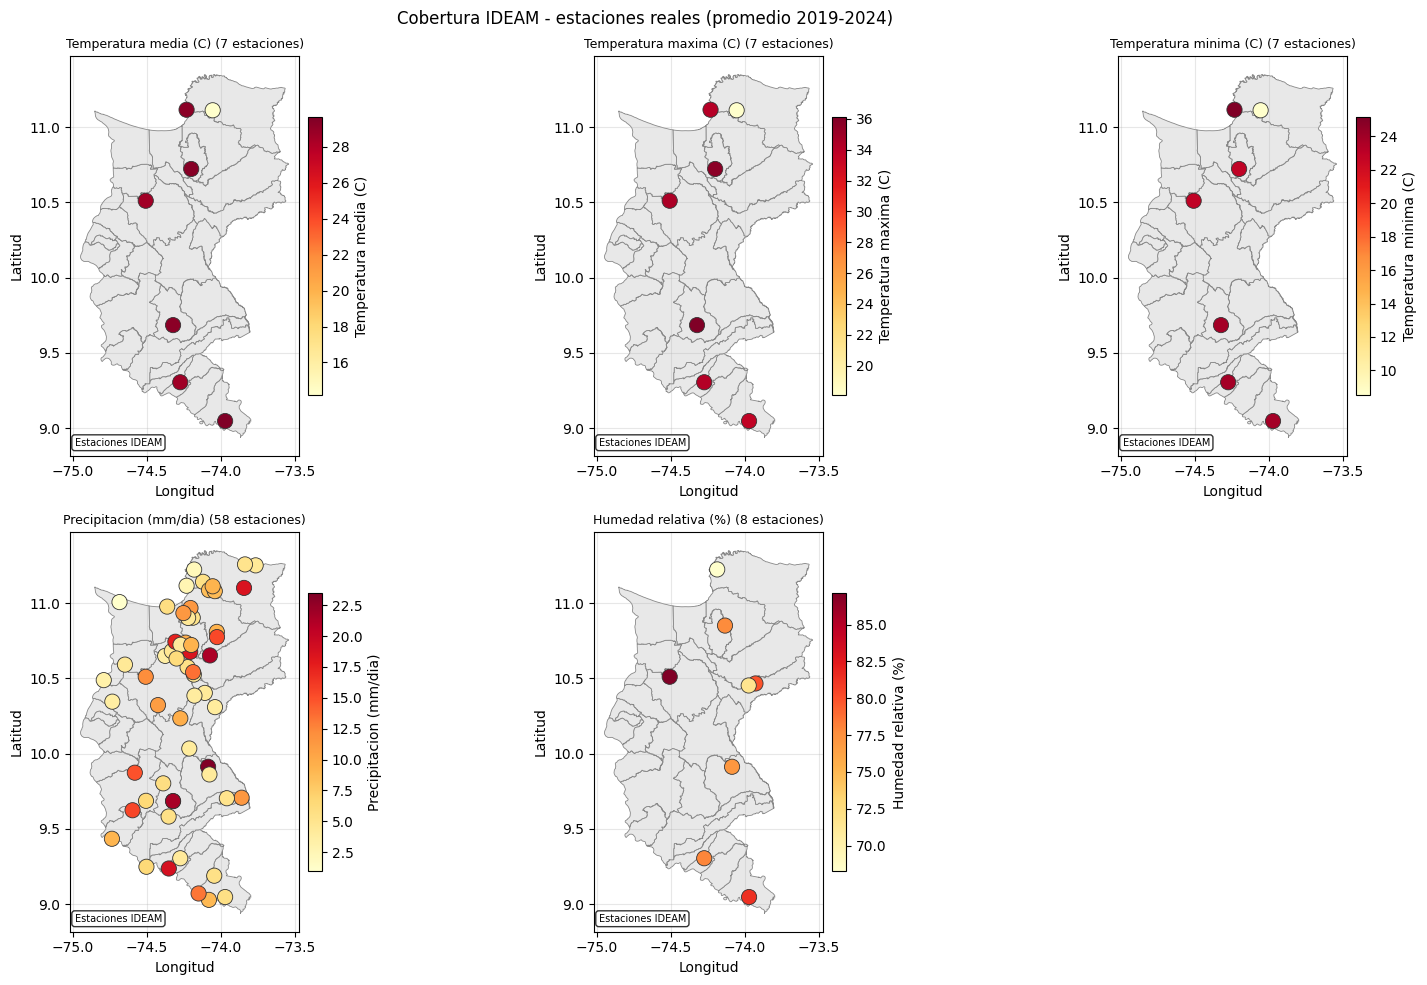

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cobertura IDEAM - estaciones reales (promedio 2019-2024)', fontsize=12)

for idx, ax in enumerate(axes.flat):
    if idx >= len(VARIABLES_IDEAM):
        ax.set_visible(False)
        continue

    nombre_var, col_estandar = list(VARIABLES_IDEAM.items())[idx]
    magdalena.plot(ax=ax, facecolor='#e8e8e8', edgecolor='#888888', linewidth=0.6, zorder=0)

    if nombre_var not in ideam_raw:
        ax.set_title(f'{VARIABLES[col_estandar]}\n(sin datos)', fontsize=9)
        continue

    df = ideam_raw[nombre_var]
    agg = df.groupby(['id_estacion', 'lat', 'lon'])[col_estandar].mean().reset_index()

    vmin, vmax = agg[col_estandar].min(), agg[col_estandar].max()
    if vmin == vmax:
        vmax = vmin + 1
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    sc = ax.scatter(
        agg['lon'], agg['lat'],
        s=120,
        c=agg[col_estandar], cmap='YlOrRd', norm=norm,
        edgecolors='#333333', linewidths=0.6, zorder=2,
    )
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label=VARIABLES[col_estandar])
    ax.set_title(f"{VARIABLES[col_estandar]} ({agg['id_estacion'].nunique()} estaciones)",
                 fontsize=9)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.text(0.02, 0.02, 'Estaciones IDEAM',
            transform=ax.transAxes, fontsize=7,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'ideam_estaciones_reales.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Validacion point-to-pixel

Para evaluar la calidad de NASA POWER, ERA5 y CHIRPS respecto a observaciones reales se usa el enfoque point-to-pixel: se descarga cada fuente exactamente en las coordenadas de cada estacion IDEAM y se comparan los valores directamente contra las observaciones terrestres.

Este enfoque es mas riguroso que interpolar el IDEAM para comparar, porque la estacion IDEAM es la observacion de referencia (ground truth) y se evalua directamente que tan bien cada fuente estima el valor en ese punto especifico.

Las metricas calculadas son:

- RMSE: error cuadratico medio. Penaliza mas los errores grandes. Mismas unidades que la variable.
- MAE: error absoluto medio. Mas robusto a valores extremos que el RMSE.
- Bias: sesgo sistematico. Positivo significa que la fuente sobreestima, negativo que subestima.

CHIRPS solo se valida para precipitacion porque es el unico parametro que provee.

In [ ]:
filas = []
for nombre_var, df in ideam_raw.items():
    est = df[['id_estacion', 'municipio', 'lat', 'lon']].drop_duplicates('id_estacion')
    filas.append(est)
coords_estaciones = pd.concat(filas).drop_duplicates('id_estacion').reset_index(drop=True)
print(f'Total estaciones unicas: {len(coords_estaciones)}')
coords_estaciones.head(10)

Total estaciones unicas: 63


,id_estacion,municipio,lat,lon
0,25025090,El Banco,9.046333,-73.970833
1,15015050,Santa Marta,11.114694,-74.231028
2,25025300,San Sebastián De Buenavista,9.683667,-74.322278
3,25025002,San Sebastián De Buenavista,9.304056,-74.273639
4,29065000,Pivijai,10.510028,-74.506667
5,29065020,Zona Bananera,10.721111,-74.199722
6,15015060,Santa Marta,11.111083,-74.054694
7,25021600,Plato,9.872500,-74.580389
8,29060350,El Retén,10.631167,-74.298583
9,28040150,Algarrobo,10.308056,-74.039222


In [ ]:
path_nasa_est = DATA_DIR / 'external' / 'clima_nasa_power_estaciones_ideam.parquet'
path_era5_est = DATA_DIR / 'external' / 'clima_era5_estaciones_ideam.parquet'

if path_nasa_est.exists():
    df_nasa_est = pd.read_parquet(path_nasa_est)
    print(f'NASA estaciones cargado desde cache: {df_nasa_est.shape}')
else:
    dfs = []
    for _, row in coords_estaciones.iterrows(): # type: ignore
        try:
            df = get_nasa_power_diario(row['lat'], row['lon'])
            df['id_estacion'] = row['id_estacion']
            dfs.append(df)
            print(f'  OK {row["id_estacion"]}')
            time.sleep(0.4)
        except Exception as e:
            print(f'  ERROR {row["id_estacion"]}: {e}')
    df_nasa_est = pd.concat(dfs, ignore_index=True)
    df_nasa_est.to_parquet(path_nasa_est, index=False)
    print(f'Guardado: {path_nasa_est}')

if path_era5_est.exists():
    df_era5_est = pd.read_parquet(path_era5_est)
    df_era5_est['fecha'] = df_era5_est['fecha'].dt.normalize()
    print(f'ERA5 estaciones cargado desde cache: {df_era5_est.shape}')
else:
    dfs = []
    for _, row in coords_estaciones.iterrows(): # type: ignore
        try:
            df = get_era5_diario(row['lat'], row['lon'])
            df['id_estacion'] = row['id_estacion']
            dfs.append(df)
            print(f'  OK {row["id_estacion"]}')
        except Exception as e:
            print(f'  ERROR {row["id_estacion"]}: {e}')
        time.sleep(7)
    df_era5_est = pd.concat(dfs, ignore_index=True)
    df_era5_est.to_parquet(path_era5_est, index=False)
    print(f'Guardado: {path_era5_est}')

NASA estaciones cargado desde cache: (138096, 7)
ERA5 estaciones cargado desde cache: (138096, 7)


In [ ]:
path_chirps_est = DATA_DIR / 'external' / 'clima_chirps_estaciones_ideam.parquet'

if path_chirps_est.exists():
    df_chirps_est = pd.read_parquet(path_chirps_est)
    print(f'CHIRPS estaciones cargado desde cache: {df_chirps_est.shape}')
else:
    est_precip = ideam_raw['precipitacion'][['id_estacion', 'lat', 'lon']].drop_duplicates('id_estacion')
    dfs = []
    for _, row in est_precip.iterrows(): # type: ignore
        try:
            punto = ee.Geometry.Point([row['lon'], row['lat']])
            chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').filterDate(START_DATE, END_DATE)

            def extraer(imagen):
                valor = imagen.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=punto,
                    scale=5000
                )
                return ee.Feature(None, {
                    'fecha': imagen.date().format('YYYY-MM-dd'),
                    'precipitacion': valor.get('precipitation')
                })

            datos = chirps.map(extraer).getInfo()['features']
            df = pd.DataFrame([{
                'fecha': pd.to_datetime(f['properties']['fecha']),
                'precipitacion': f['properties'].get('precipitacion'),
                'id_estacion': row['id_estacion']
            } for f in datos])
            dfs.append(df)
            print(f'  OK {row["id_estacion"]}')
        except Exception as e:
            print(f'  ERROR {row["id_estacion"]}: {e}')
    df_chirps_est = pd.concat(dfs, ignore_index=True)
    df_chirps_est.to_parquet(path_chirps_est, index=False)
    print(f'Guardado: {path_chirps_est}')

  OK 25025090
  OK 15015050
  OK 25021600
  OK 29060350
  OK 28040150
  OK 15010020
  OK 29060150
  OK 29060560
  OK 25021610
  OK 29060030
  OK 28040320
  OK 29060140
  OK 29060060
  OK 25025000
  OK 29060160
  OK 29060340
  OK 25021500
  OK 25025300
  OK 15010310
  OK 29060040
  OK 29020020
  OK 29060170
  OK 15010300
  OK 28040360
  OK 15010501
  OK 25021620
  OK 29060180
  OK 29060200
  OK 25021190
  OK 29060210
  OK 1501500196
  OK 25025002
  OK 29060080
  OK 25021200
  OK 29060250
  OK 29065000
  OK 25021040
  OK 15010010
  OK 28040100
  OK 25021630
  OK 29065020
  OK 29060270
  OK 29050020
  OK 28040140
  OK 29060280
  OK 15015060
  OK 29060070
  OK 29060540
  OK 25021380
  OK 25020900
  OK 29060100
  OK 25021030
  OK 29060310
  OK 29060120
  OK 25021020
  OK 29050010
  OK 28040300
  OK 15010040
Guardado: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\data\external\clima_chirps_estaciones_ideam.parquet


In [ ]:
def calcular_metricas(y_obs, y_pred):
    
    mask = ~(np.isnan(y_obs) | np.isnan(y_pred))
    if mask.sum() < 10:
        return {'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan, 'N': int(mask.sum())}
    yo = y_obs[mask]
    yp = y_pred[mask]
    rmse = np.sqrt(mean_squared_error(yo, yp))
    mae = mean_absolute_error(yo, yp)
    bias = float(np.mean(yp - yo))
    return {
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'Bias': round(bias, 3),
        'N': int(mask.sum())
    }


rows = []
for nombre_var, col_v in VARIABLES_IDEAM.items():
    if nombre_var not in ideam_raw:
        continue
    df_v = ideam_raw[nombre_var][['id_estacion', 'fecha', col_v, 'lat', 'lon']]

    for id_est in df_v['id_estacion'].unique():
        ideam_s = df_v[df_v['id_estacion'] == id_est].set_index('fecha')
        nasa_s = df_nasa_est[df_nasa_est['id_estacion'] == id_est].set_index('fecha')
        era5_s = df_era5_est[df_era5_est['id_estacion'] == id_est].set_index('fecha')
        lat = float(ideam_s['lat'].iloc[0])
        lon = float(ideam_s['lon'].iloc[0])

        mn = ideam_s[[col_v]].join(nasa_s[[col_v]], rsuffix='_nasa', how='inner')
        me = ideam_s[[col_v]].join(era5_s[[col_v]], rsuffix='_era5', how='inner')

        met_n = calcular_metricas(mn[col_v].values, mn[f'{col_v}_nasa'].values)
        met_e = calcular_metricas(me[col_v].values, me[f'{col_v}_era5'].values)

        rows.append({'variable': col_v, 'id_estacion': id_est, 'lat': lat, 'lon': lon,
                     'fuente': 'NASA POWER', **met_n})
        rows.append({'variable': col_v, 'id_estacion': id_est, 'lat': lat, 'lon': lon,
                     'fuente': 'ERA5', **met_e})

        # CHIRPS solo para precipitacion
        if col_v == 'precipitacion' and 'df_chirps_est' in dir():
            chirps_s = df_chirps_est[df_chirps_est['id_estacion'] == id_est].set_index('fecha')
            mc = ideam_s[[col_v]].join(chirps_s[['precipitacion']], rsuffix='_chirps', how='inner')
            met_c = calcular_metricas(mc[col_v].values, mc['precipitacion_chirps'].values)
            rows.append({'variable': col_v, 'id_estacion': id_est, 'lat': lat, 'lon': lon,
                         'fuente': 'CHIRPS', **met_c})

df_metricas = pd.DataFrame(rows)
print(f'Metricas calculadas: {len(df_metricas)} filas')
df_metricas.head(10)

Metricas calculadas: 232 filas


,variable,id_estacion,lat,lon,fuente,RMSE,MAE,Bias,N
0,t2m_media,25025090,9.046333,-73.970833,NASA POWER,2.019,1.667,-0.898,1425
1,t2m_media,25025090,9.046333,-73.970833,ERA5,1.465,1.234,-1.062,1425
2,t2m_media,15015050,11.114694,-74.231028,NASA POWER,1.895,1.730,-1.705,412
3,t2m_media,15015050,11.114694,-74.231028,ERA5,1.137,0.954,-0.872,412
4,t2m_media,25025300,9.683667,-74.322278,NASA POWER,2.128,1.733,1.251,1005
5,t2m_media,25025300,9.683667,-74.322278,ERA5,1.310,1.071,-0.047,1005
6,t2m_media,25025002,9.304056,-74.273639,NASA POWER,2.276,1.856,1.407,1920
7,t2m_media,25025002,9.304056,-74.273639,ERA5,1.027,0.813,0.203,1920
8,t2m_media,29065000,10.510028,-74.506667,NASA POWER,1.309,1.071,0.152,1918
9,t2m_media,29065000,10.510028,-74.506667,ERA5,1.116,0.917,0.514,1918


In [ ]:
resumen = (
    df_metricas
    .groupby(['variable', 'fuente'])
    .agg(
        RMSE_media=('RMSE', 'mean'),
        MAE_media=('MAE', 'mean'),
        Bias_medio=('Bias', 'mean'),
        N_estaciones=('id_estacion', 'count')
    )
    .round(3)
    .reset_index()
)
resumen['Variable'] = resumen['variable'].map(VARIABLES)
print('Comparacion de fuentes contra observaciones IDEAM (2019-2024):')
resumen[['Variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio', 'N_estaciones']]

Comparacion de fuentes contra observaciones IDEAM (2019-2024):


,Variable,fuente,RMSE_media,MAE_media,Bias_medio,N_estaciones
0,Humedad relativa (%),ERA5,11.255,8.422,0.239,8
1,Humedad relativa (%),NASA POWER,15.748,13.201,-8.025,8
2,Precipitacion (mm/dia),CHIRPS,16.783,9.162,-3.873,58
3,Precipitacion (mm/dia),ERA5,18.035,10.451,-0.619,58
4,Precipitacion (mm/dia),NASA POWER,17.659,8.957,-5.728,58
5,Temperatura maxima (C),ERA5,2.467,2.123,-1.658,7
6,Temperatura maxima (C),NASA POWER,3.790,3.350,1.064,7
7,Temperatura media (C),ERA5,1.223,1.000,-0.290,7
8,Temperatura media (C),NASA POWER,2.819,2.537,1.132,7
9,Temperatura minima (C),ERA5,2.467,2.088,1.972,7


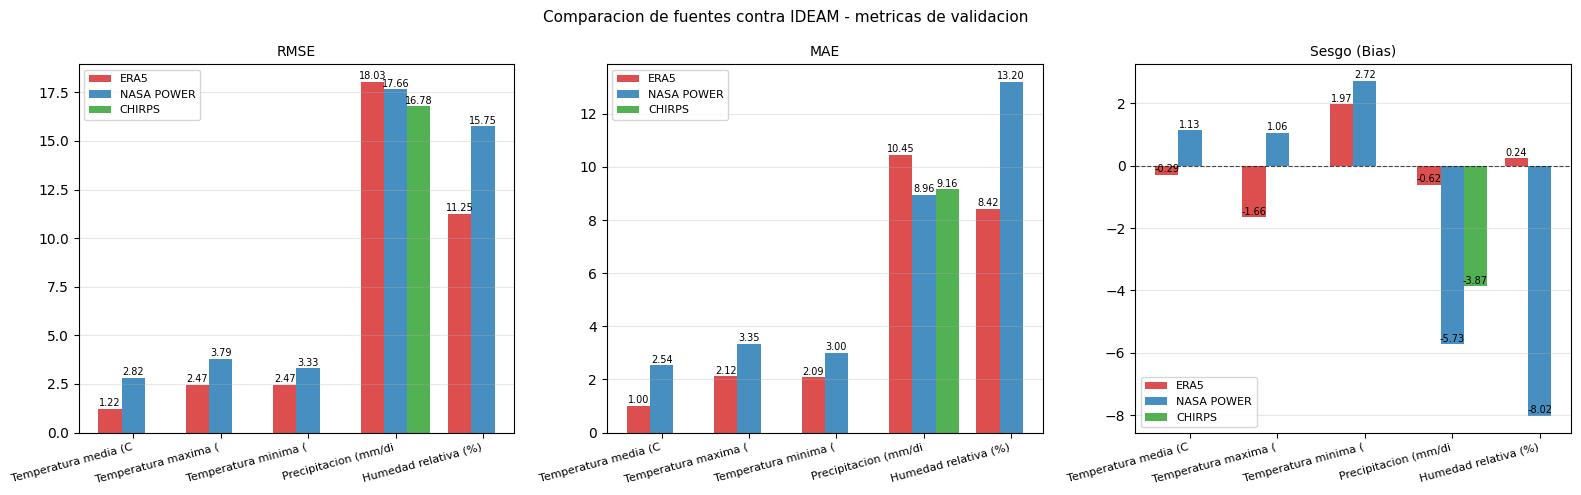

In [ ]:
vars_list = list(VARIABLES.keys())
etiquetas_var = [VARIABLES[v][:20] for v in vars_list]
x = np.arange(len(vars_list))

metricas_defs = [('RMSE', 'RMSE'), ('MAE', 'MAE'), ('Bias', 'Sesgo (Bias)')]
colores_fuente = {'NASA POWER': '#1f77b4', 'ERA5': '#d62728', 'CHIRPS': '#2ca02c'}

resumen_plot = (
    df_metricas
    .groupby(['variable', 'fuente'])[['RMSE', 'MAE', 'Bias']]
    .mean()
    .reset_index()
)

fuentes_disponibles = resumen_plot['fuente'].unique().tolist()
n_fuentes = len(fuentes_disponibles)
width = 0.8 / n_fuentes

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparacion de fuentes contra IDEAM - metricas de validacion', fontsize=11)

for idx, (met_col, met_label) in enumerate(metricas_defs):
    ax = axes[idx]
    for k, fuente in enumerate(fuentes_disponibles):
        vals = []
        for col_v in vars_list:
            row = resumen_plot[
                (resumen_plot['variable'] == col_v) & (resumen_plot['fuente'] == fuente)
            ]
            vals.append(float(row[met_col].iloc[0]) if len(row) > 0 else np.nan)
        offset = (k - (n_fuentes - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=fuente,
                      color=colores_fuente.get(fuente, '#888888'), alpha=0.82)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.02,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7)

    if met_col == 'Bias':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas_var, fontsize=8, rotation=15, ha='right')
    ax.set_title(met_label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'validacion_metricas_resumen.png',
            dpi=150, bbox_inches='tight')
plt.show()

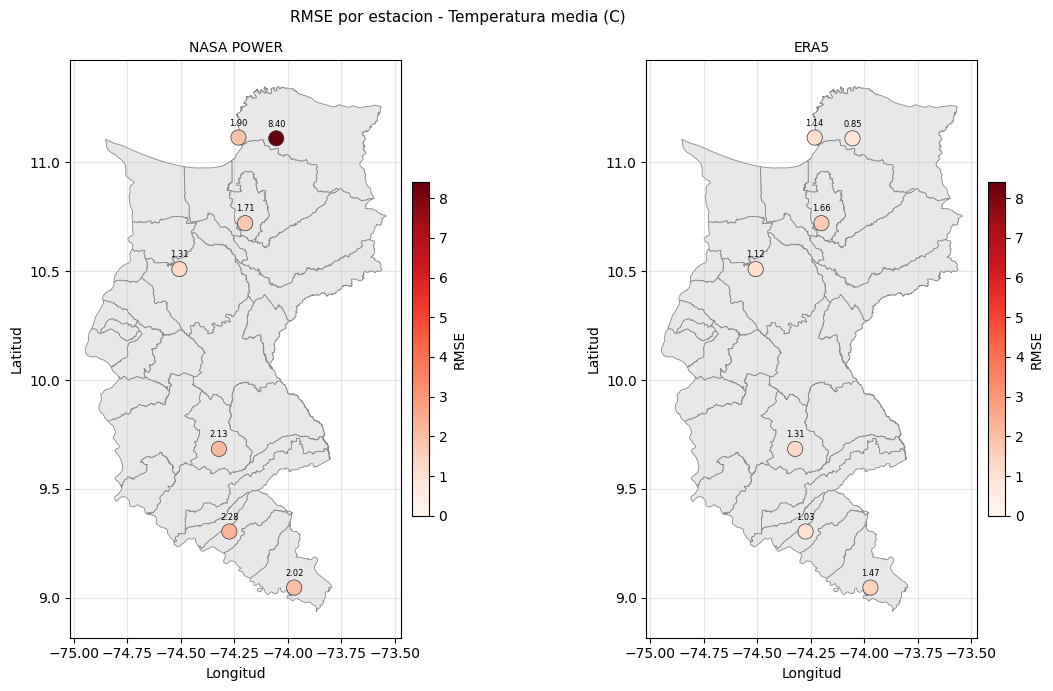

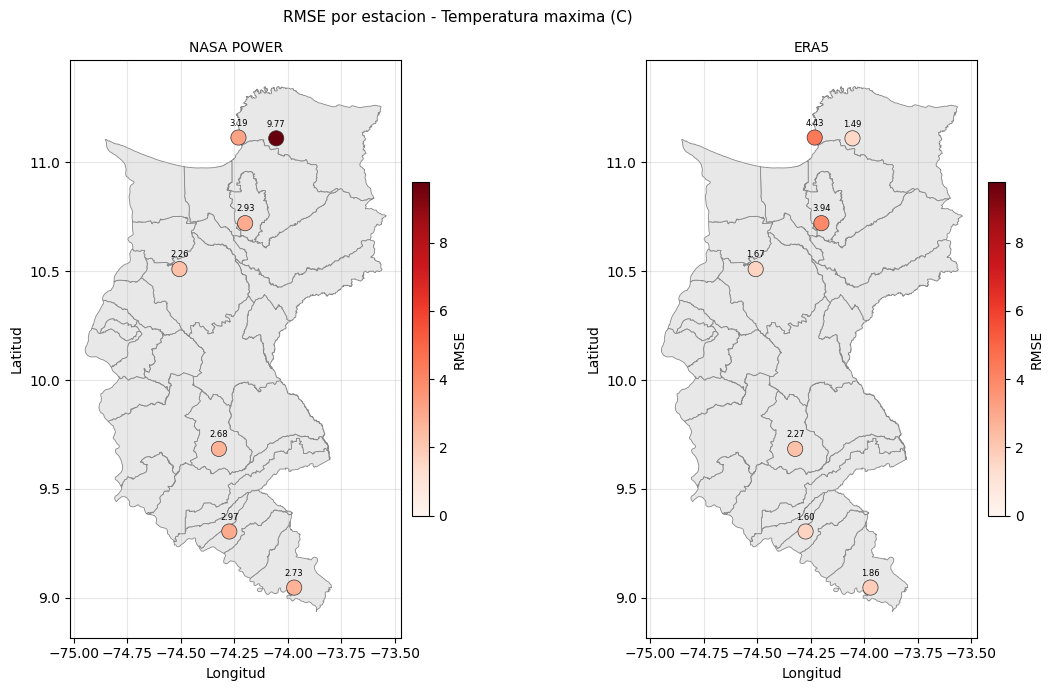

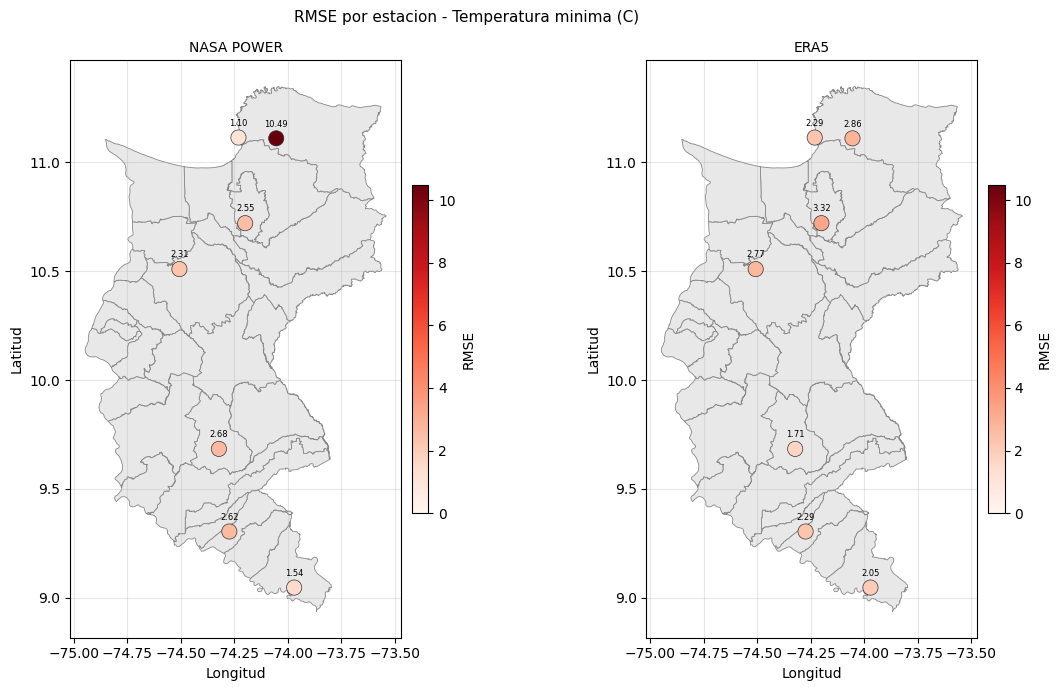

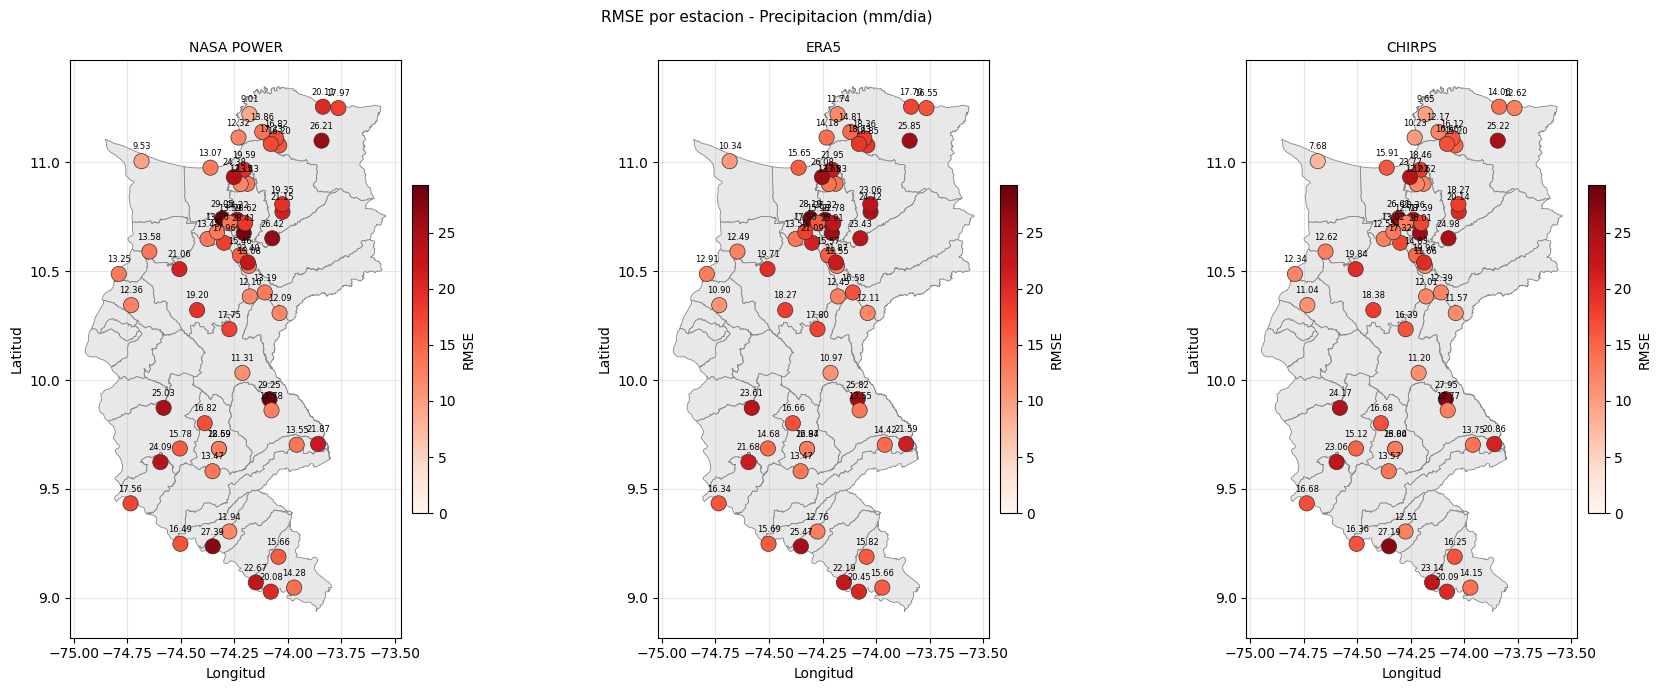

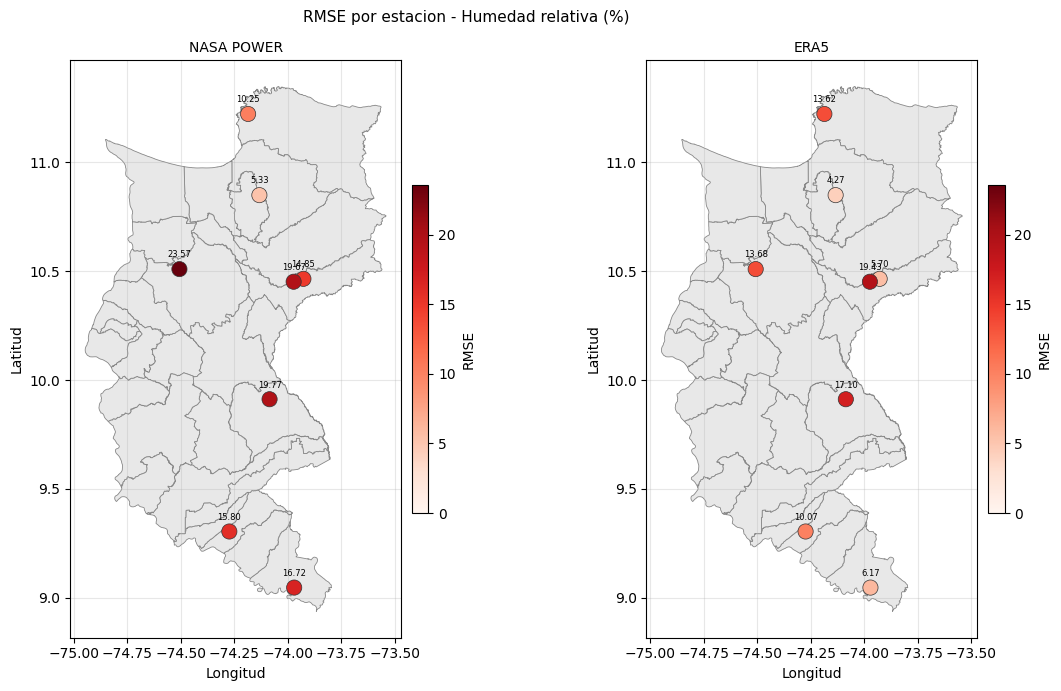

In [ ]:
vars_list_mapa = list(VARIABLES_IDEAM.values())

for col_v in vars_list_mapa:
    fuentes_var = df_metricas[df_metricas['variable'] == col_v]['fuente'].unique()
    n_fuentes_var = len(fuentes_var)
    
    sub_var = df_metricas[df_metricas['variable'] == col_v].dropna(subset=['RMSE'])
    vmax_global = sub_var['RMSE'].max()
    norm = mcolors.Normalize(vmin=0, vmax=vmax_global if vmax_global > 0 else 1)

    fig, axes = plt.subplots(1, n_fuentes_var, figsize=(6 * n_fuentes_var, 7))
    if n_fuentes_var == 1:
        axes = [axes]
    fig.suptitle(f'RMSE por estacion - {VARIABLES[col_v]}', fontsize=11)

    for ax, fuente in zip(axes, fuentes_var):
        sub = df_metricas[
            (df_metricas['variable'] == col_v) &
            (df_metricas['fuente'] == fuente)
        ].dropna(subset=['RMSE'])

        magdalena.plot(ax=ax, facecolor='#e8e8e8', edgecolor='#888888', linewidth=0.6, zorder=0)

        if len(sub) > 0:
            sc = ax.scatter(
                sub['lon'], sub['lat'],
                s=120,
                c=sub['RMSE'], cmap='Reds', norm=norm,
                edgecolors='#333333', linewidths=0.5, zorder=2,
            )
            plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='RMSE')
            for _, row in sub.iterrows():
                ax.annotate(f"{row['RMSE']:.2f}", (row['lon'], row['lat']),
                            fontsize=6, ha='center', va='bottom',
                            xytext=(0, 7), textcoords='offset points')

        ax.set_title(fuente, fontsize=10)
        ax.set_xlabel('Longitud')
        ax.set_ylabel('Latitud')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    nombre_archivo = col_v.replace('/', '_')
    plt.savefig(PROJECT_ROOT / 'outputs' / f'rmse_mapa_{nombre_archivo}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# 7. Seleccion de fuente por variable

Con base en las metricas de la seccion anterior se selecciona la fuente principal para cada variable. El criterio es el menor RMSE medio entre todas las estaciones disponibles para esa variable.

Esta seccion documenta la decision metodologica central del notebook. La seleccion debe actualizarse manualmente con los resultados reales de la validacion.

In [17]:
# Seleccion automatica de la fuente con menor RMSE medio por variable
seleccion = (
    resumen
    .sort_values('RMSE_media')
    .groupby('variable')
    .first()
    .reset_index()[['variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio']]
)
seleccion['Variable'] = seleccion['variable'].map(VARIABLES)

print('Fuente seleccionada por variable (menor RMSE):')
print(seleccion[['Variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio']].to_string(index=False))

# Diccionario fuente_por_variable para usar en la construccion del dataset
fuente_por_variable = dict(zip(seleccion['variable'], seleccion['fuente']))
print('\nDiccionario de seleccion:')
for var, fuente in fuente_por_variable.items():
    print(f'  {var}: {fuente}')

Fuente seleccionada por variable (menor RMSE):
              Variable fuente  RMSE_media  MAE_media  Bias_medio
  Humedad relativa (%)   ERA5      11.255      8.422       0.239
Precipitacion (mm/dia) CHIRPS      16.783      9.162      -3.873
Temperatura maxima (C)   ERA5       2.467      2.123      -1.658
 Temperatura media (C)   ERA5       1.223      1.000      -0.290
Temperatura minima (C)   ERA5       2.467      2.088       1.972

Diccionario de seleccion:
  humedad: ERA5
  precipitacion: CHIRPS
  t2m_max: ERA5
  t2m_media: ERA5
  t2m_min: ERA5


# 8. Dataset consolidado - agregacion semanal

Se construye el dataset final con la fuente ganadora para cada variable. Para cada variable se toma unicamente la fuente seleccionada en la seccion anterior.

Se agrega a semana epidemiologica con convencion Sunday-start (OPS/SIVIGILA). Para convertir de la convencion ISO de pandas (Monday-start) a la convencion OPS (Sunday-start) se desplaza la fecha un dia hacia adelante antes de calcular la semana.

Para precipitacion se usa suma semanal. Para el resto se usa promedio semanal.

In [ ]:
def agregar_semanal(df, col_vars, col_suma=None):
    df = df.copy()
    fecha_aj = pd.to_datetime(df['fecha']) + pd.Timedelta(days=1)
    df['año_epi'] = fecha_aj.dt.isocalendar().year.astype(int)
    df['semana_epi'] = fecha_aj.dt.isocalendar().week.astype(int)
    agg_dict = {}
    for col in col_vars:
        if col not in df.columns:
            continue
        if col_suma and col in col_suma:
            agg_dict[col] = (col, 'sum')
        else:
            agg_dict[col] = (col, 'mean')
    return df.groupby(['municipio', 'año_epi', 'semana_epi']).agg(**agg_dict).reset_index()


cols_clima = list(VARIABLES.keys())

# Mapeo de fuente a DataFrame diario
df_por_fuente = {
    'NASA POWER': df_nasa_diario,
    'ERA5': df_era5_diario,
    'CHIRPS': df_chirps_diario,
}

# Construir dataset con la fuente ganadora por variable
# Para cada variable se extrae solo la columna ganadora de su fuente
dfs_sem = []
for col_v, fuente in fuente_por_variable.items():
    df_fuente = df_por_fuente.get(fuente)
    if df_fuente is None or col_v not in df_fuente.columns:
        print(f'  {col_v}: fuente {fuente} no disponible, se omite')
        continue
    col_suma = [col_v] if col_v == 'precipitacion' else None
    df_v = agregar_semanal(df_fuente[['fecha', 'municipio', col_v]], [col_v], col_suma=col_suma)
    dfs_sem.append(df_v)
    print(f'  {col_v}: fuente={fuente}')

# Merge de todas las variables
df_clima = dfs_sem[0]
for df_v in dfs_sem[1:]:
    df_clima = df_clima.merge(df_v, on=['municipio', 'año_epi', 'semana_epi'], how='outer')

print(f'\nDataset climatico consolidado:')
print(f'  Shape: {df_clima.shape}')
print(f'  Municipios: {df_clima["municipio"].nunique()}')
print(f'  Semanas: {df_clima.groupby(["año_epi","semana_epi"]).ngroups}')
print(f'  Columnas: {df_clima.columns.tolist()}')

(DATA_DIR / 'processed').mkdir(parents=True, exist_ok=True)
df_clima.to_parquet(DATA_DIR / 'processed' / 'clima_semanal_magdalena.parquet', index=False)
print(f'\nGuardado: data/processed/clima_semanal_magdalena.parquet')
df_clima.head()

# 9. Cruce con SIVIGILA - dataset final

Se cruza el dataset climatico semanal con los casos de dengue confirmados del SIVIGILA en el Magdalena. El resultado es el dataset con una fila por (municipio, año_epi, semana_epi) que incluye casos y todas las variables climaticas.

Para el cruce por nombre de municipio se normalizan los textos eliminando tildes, espacios extra y convirtiendo a mayusculas, evitando que diferencias de escritura entre fuentes rompan el join.

In [ ]:
def asignar_semana_epi(fecha):
    fecha_aj = pd.to_datetime(fecha, errors='coerce') + pd.Timedelta(days=1)
    iso = fecha_aj.dt.isocalendar()
    return pd.DataFrame({
        'año_epi': iso['year'].astype('Int64'),
        'semana_epi': iso['week'].astype('Int64'),
    })


df_clean_path = DATA_DIR / 'processed' / 'df_clean.parquet'
if not df_clean_path.exists():
    raise FileNotFoundError(
        f'No existe {df_clean_path}. Ejecuta el notebook 01_eda.ipynb primero.'
    )
df_clean = pd.read_parquet(df_clean_path)
print(f'df_clean: {df_clean.shape}')

In [ ]:
DPTO_MAGDALENA = 47

df_dengue = df_clean[
    df_clean['cod_eve'].isin([210, 220]) &
    df_clean['mun_valido'] &
    (df_clean['cod_dpto_o'] == DPTO_MAGDALENA) &
    df_clean['tip_cas'].isin([2, 3, 5])
].copy()

sem = asignar_semana_epi(df_dengue['fec_not'])
df_dengue['año_epi'] = sem['año_epi']
df_dengue['semana_epi'] = sem['semana_epi']

casos_sem = (
    df_dengue
    .groupby(['nom_mun_o', 'año_epi', 'semana_epi'])
    .size()
    .reset_index(name='casos')
    .rename(columns={'nom_mun_o': 'municipio'})
)


def normalizar_nombre(s):
    return (
        s.fillna('').astype(str).str.strip().str.upper()
        .str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii')
    )


df_clima['_key'] = normalizar_nombre(df_clima['municipio'])
casos_sem['_key'] = normalizar_nombre(casos_sem['municipio'])

df_final = df_clima.merge(
    casos_sem.drop(columns=['municipio']),
    on=['_key', 'año_epi', 'semana_epi'],
    how='left',
).drop(columns=['_key'])

df_final['casos'] = df_final['casos'].fillna(0).astype(int)

cols_orden = ['municipio', 'año_epi', 'semana_epi', 'casos'] + [
    c for c in df_final.columns
    if c not in ['municipio', 'año_epi', 'semana_epi', 'casos']
]
df_final = df_final[cols_orden]

print(f'Dataset final:')
print(f'  Shape: {df_final.shape}')
print(f'  Municipios: {df_final["municipio"].nunique()}')
print(f'  Total casos: {df_final["casos"].sum():,}')
print(f'  Semanas con casos > 0: {(df_final["casos"] > 0).sum():,}')

df_final.to_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet', index=False)
print('\nGuardado: data/processed/dataset_modelado_magdalena.parquet')
df_final.head()

# Referencias

- Li et al. (2020). Temperature and dengue transmission: a systematic review and meta-analysis. PLOS Neglected Tropical Diseases.
- Costa et al. (2010). Effects of temperature and humidity on Aedes aegypti survival and reproduction.
- Shaman & Karspeck (2012). Forecasting seasonal outbreaks of influenza. PNAS.
- Retalis et al. (2017). Validation of CHIRPS satellite-based precipitation estimates over Greece. Remote Sensing.
- Dinku et al. (2018). Validation of satellite rainfall products over East Africa. Journal of Hydrometeorology.
- Zhao et al. [1], Sebastianelli et al. [17], Hasan et al. [9], Karasinghe et al. [10], Rahman et al. [12] (en el estado del arte del proyecto).